In [ ]:
from scripts.BuildBandit import Build
import numpy as np
from scripts.AbstractExperiments import ExperimentRunner
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.optimize import curve_fit
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
})
configs = []
DeafaultRanks = [1]
DefaultActions = 25
DefaultBranches = 25
DefaultTheories = 25

minActionsIn=10
maxActionsEx=101
actionStep=10

minTheoriesIn=10
maxTheoriesEx=101
theoriesStep=10

minBranchesIn=10
maxBranchesEx=101
branchesStep=10

Env_reps = 5
config_reps = 5

for i in range(minActionsIn,maxActionsEx,actionStep):
    for r in DeafaultRanks:
        configs += {"Name": f"Action_{i}_r{r}", "Theories": DefaultTheories, "ranks":r, "actions":i, "minBranches":DefaultBranches, "maxBranches":DefaultBranches+1},

for i in range(minTheoriesIn,maxTheoriesEx,theoriesStep):
    ranks = 1
    configs += {"Name": f"Theories_{i}_r{ranks}", "Theories": i, "ranks":ranks, "actions":DefaultActions, "minBranches":DefaultBranches, "maxBranches":DefaultBranches+1},
    
for i in range(minBranchesIn,maxBranchesEx,branchesStep):
    for r in DeafaultRanks:
        configs += {"Name": f"Branches_{i}_r{r}", "Theories": DefaultTheories, "ranks":r, "actions":DefaultActions, "minBranches":i, "maxBranches":i+1},

for i, c in enumerate(configs):
    c["Name"] = f"{i}_{c["Name"]}"
    c["Considerations"] = c["Theories"]
    c["N"] = c["minBranches"] * c["actions"] * c["Theories"]

configs = []
for acts in range(minActionsIn,maxActionsEx,actionStep):
    for ths in range(minTheoriesIn,maxTheoriesEx,theoriesStep):
        for brs in range(minBranchesIn,maxBranchesEx,branchesStep):
            configs += {"Name": f"Test", "Theories": ths, "ranks":r, "actions":acts, "minBranches":brs, "maxBranches":brs+1},
            
for i, c in enumerate(configs):
    c["Name"] = f"{i}_{c["Name"]}"

er = ExperimentRunner("Bandit", configs, outFolder="Bandit")

In [ ]:
# Takes like 20 minutes for 2 con reps * 2 env reps
# Takes like 48 minutes for 5 con reps * 5 env reps
for i, el in enumerate(configs):
    for con_rep in range(config_reps):
        theories = el["Theories"]
        ranks = el["ranks"]
        actions = el["actions"]
        minBranches = el["minBranches"]
        maxBranches = el["maxBranches"]
        # Generates and saves environment satisfying parameters to fileName
        o = Build(fileName=er.getMdpFileName(el["Name"], con_rep), fileAbsolute=True,
            theories=theories, numOfRanks=ranks, 
            numOfActions=actions, minBranches=minBranches, 
            maxBranches=maxBranches)

Written to `/home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Bandit/Bandit/mdps/0_Test_con0.json`
Written to `/home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Bandit/Bandit/mdps/0_Test_con1.json`
Written to `/home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Bandit/Bandit/mdps/0_Test_con2.json`
Written to `/home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Bandit/Bandit/mdps/0_Test_con3.json`
Written to `/home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Bandit/Bandit/mdps/0_Test_con4.json`
Written to `/home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Bandit/Bandit/mdps/1_Test_con0.json`
Written to `/home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Bandit/Bandit/mdps/1_Test_con1.json`
Written to `/home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Bandit/Bandit/mdps/1_Test_con2.json`
Written to `/home/psiko/Programming/MoralPlanner/Notebooks/../Data/Exper

In [ ]:
# Takes like 20 minutes for 2 con reps * 2 env rep
# took 82 mins for 5*5
er.runMEHR(config_reps, Env_reps)

Start 1/25000 -- /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Bandit/Bandit/mdps/0_Test_con0.json
THE 2026 MACHINE ETHICS HYPOTHETICAL RETROSPECTION PLANNER (MEHR-PLAN)
JSON file '/home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Bandit/Bandit/raw/0_Test_con0_rep0.json' created successfully!
Start 2/25000 -- /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Bandit/Bandit/mdps/0_Test_con0.json
THE 2026 MACHINE ETHICS HYPOTHETICAL RETROSPECTION PLANNER (MEHR-PLAN)
JSON file '/home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Bandit/Bandit/raw/0_Test_con0_rep1.json' created successfully!
Start 3/25000 -- /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Bandit/Bandit/mdps/0_Test_con0.json
THE 2026 MACHINE ETHICS HYPOTHETICAL RETROSPECTION PLANNER (MEHR-PLAN)
JSON file '/home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Bandit/Bandit/raw/0_Test_con0_rep2.json' created successfully!
Star

In [5]:
def ProcessValue(df_, val_name='Action', val_name_label=None, fig_size=(7,6), use_error_bars=False, title=None):
    # Group by actions only and compute summary statistics for Mehr_time
    summary_df = df_.groupby([val_name], as_index=False).agg({
        'MEHR Time': ['mean', 'min', 'max']
    })
    summary_df.columns = [val_name, 'Mehr_time_mean', 'Mehr_time_min', 'Mehr_time_max']

    x = summary_df[val_name]
    y = summary_df['Mehr_time_mean']

    # Plot number of actions against average Mehr_time with min/max bars
    
    def linear(x, m, b):
        return m * x + b

    def power_law(x, a, b, c):
        return a * np.power(x, b) + c
    
    def exp_law(x, a, b, c):
        return a * np.exp(b * c)
    
    models = {
        "Linear": {
            "function": linear,
            "style": {"color": "#009E73", "linestyle": "--"},
            "equation": lambda p : rf"$y={p[0]:.3g} x {p[1]:+.3g}$",
        },
        "Power": {
            "function": power_law,
            "style": {"color": "#D55E00", "linestyle": "--"},
            "equation": lambda p: rf"$y={p[0]:.3g}x^{{{p[1]:.3g}}}$",
        },
    }
        
    def linear(x, m):
        return m * x

    def power_law(x, a, b):
        return a * np.power(x, b)
    models = {
        "Linear": {
            "function": linear,
            "style": {"color": "#009E73", "linestyle": "--"},
            "equation": lambda p : rf"$y={p[0]:.3g} x$",
        },
        "Power": {
            "function": power_law,
            "style": {"color": "#D55E00", "linestyle": "--"},
            "equation": lambda p: rf"$y={p[0]:.3g}x^{{{p[1]:.3g}}}$",
        },
    }
    fig, ax = plt.subplots(figsize=fig_size)
    if use_error_bars:
        ax.errorbar(x, y,
                yerr=[y - summary_df['Mehr_time_min'], summary_df['Mehr_time_max'] - y],
                fmt='o', markersize=8, markeredgecolor='white', markeredgewidth=0.8,
                capsize=5, linestyle='none', ecolor='gray', color='black', zorder=5)
    else:
       ax.scatter(x, y, s=65, marker='o', color='black',
               edgecolor='white', linewidth=0.8, zorder=5)
    # Will store the parameters fitting each function
    fit_metrics = {}
    x_fit = np.linspace(x.min(), x.max(), 300)
    for model_name, model in models.items():
        parameters, _ = curve_fit(model["function"], x, y, maxfev=20_000)

        # Get y prediction for all x values and calculate error values
        y_pred = model["function"](x, *parameters)
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        r_squared = r2_score(y, y_pred)

        fit_metrics[model_name] = {
            "parameters": parameters,
            "RMSE": rmse,
            "R2": r_squared,
        }

        label = (
            f"{model_name}: {model['equation'](parameters)}\n"
            rf"RMSE={rmse:.3g}, $R^2$={r_squared:.3f}"
        )
        ax.plot(
            x_fit,
            model["function"](x_fit, *parameters),
            linewidth=2,
            label=label,
            **model["style"]
            
        )

    
    #ax = plt.gca()
    #ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    if val_name_label is None:
        val_name_label = val_name
    plt.xlabel(val_name_label)
    plt.ylabel('Mean CPU time (microseconds)')
    if title is None:
        title = f"Number of {val_name_label} against MEHR CPU time"
    plt.title(title)
    plt.grid(True, color="0.9", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.legend()
    fig.tight_layout()
    plt.savefig(f"{er.figuresFolder}/{val_name}_VS_Time.pdf") 
    plt.show()

In [6]:
# Takes like 7 minutes for 2 con reps * 2 env reps
er.extractData(config_reps, Env_reps)
df = pd.DataFrame(er.data)
df["Config_Index"] = pd.to_numeric(df["Configuration"].str.split("_").str[0])
df["Theories"] = pd.to_numeric(df["Theories"])
for i in df.index:
    df.loc[i, "Actions"] = configs[df.loc[i,"Config_Index"]]["actions"]
    df.loc[i, "Branches"] = configs[df.loc[i,"Config_Index"]]["minBranches"]
df['N'] = df['Actions'] * df['Branches'] * df['Theories']
df

,Configuration,Configuration Repetition,Environment Repetition,Theories,Considerations,Total Time,Heuristic Time,Planning Time,Solution Extraction Time,MEHR Time,...,C_94,C_95,C_96,C_97,C_98,C_99,Config_Index,Actions,Branches,N
0,0_Test,0,0,10,"['C_0', 'C_1', 'C_2', 'C_3', 'C_4', 'C_5', 'C_...",298,0,0,234,64,...,N/A,N/A,N/A,N/A,N/A,N/A,0,10.0,10.0,1000.0
1,0_Test,0,1,10,"['C_0', 'C_1', 'C_2', 'C_3', 'C_4', 'C_5', 'C_...",265,0,0,225,40,...,N/A,N/A,N/A,N/A,N/A,N/A,0,10.0,10.0,1000.0
2,0_Test,0,2,10,"['C_0', 'C_1', 'C_2', 'C_3', 'C_4', 'C_5', 'C_...",279,0,0,228,51,...,N/A,N/A,N/A,N/A,N/A,N/A,0,10.0,10.0,1000.0
3,0_Test,0,3,10,"['C_0', 'C_1', 'C_2', 'C_3', 'C_4', 'C_5', 'C_...",227,0,0,188,39,...,N/A,N/A,N/A,N/A,N/A,N/A,0,10.0,10.0,1000.0
4,0_Test,0,4,10,"['C_0', 'C_1', 'C_2', 'C_3', 'C_4', 'C_5', 'C_...",228,0,0,189,39,...,N/A,N/A,N/A,N/A,N/A,N/A,0,10.0,10.0,1000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,999_Test,4,0,100,"['C_0', 'C_1', 'C_2', 'C_3', 'C_4', 'C_5', 'C_...",216883,0,0,167829,49054,...,97.0,84.0,69.0,3.0,5.0,68.0,999,100.0,100.0,1000000.0
24996,999_Test,4,1,100,"['C_0', 'C_1', 'C_2', 'C_3', 'C_4', 'C_5', 'C_...",215227,0,0,166999,48228,...,97.0,84.0,69.0,3.0,5.0,68.0,999,100.0,100.0,1000000.0
24997,999_Test,4,2,100,"['C_0', 'C_1', 'C_2', 'C_3', 'C_4', 'C_5', 'C_...",214893,0,0,166040,48853,...,97.0,84.0,69.0,3.0,5.0,68.0,999,100.0,100.0,1000000.0
24998,999_Test,4,3,100,"['C_0', 'C_1', 'C_2', 'C_3', 'C_4', 'C_5', 'C_...",219827,0,0,170703,49124,...,97.0,84.0,69.0,3.0,5.0,68.0,999,100.0,100.0,1000000.0


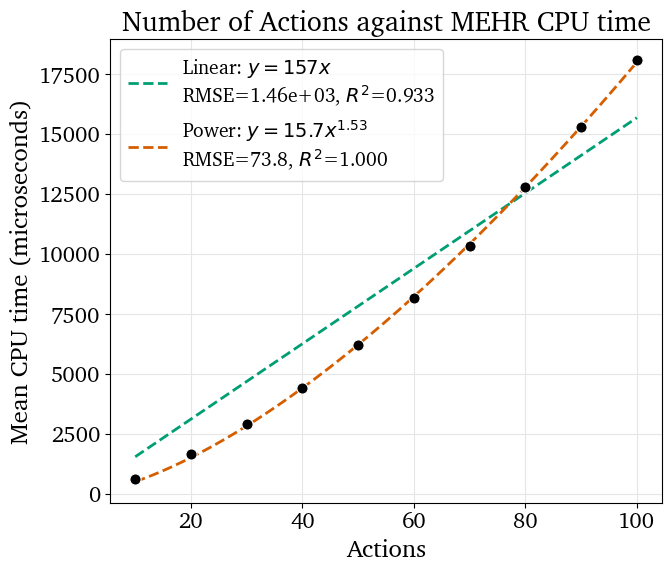

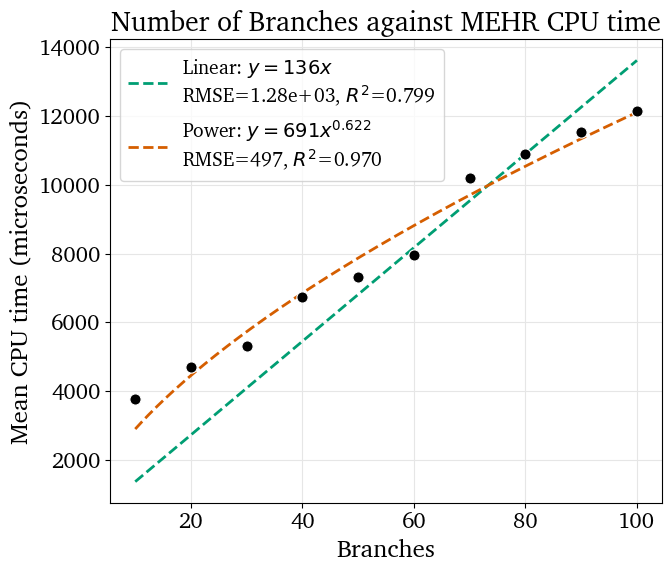

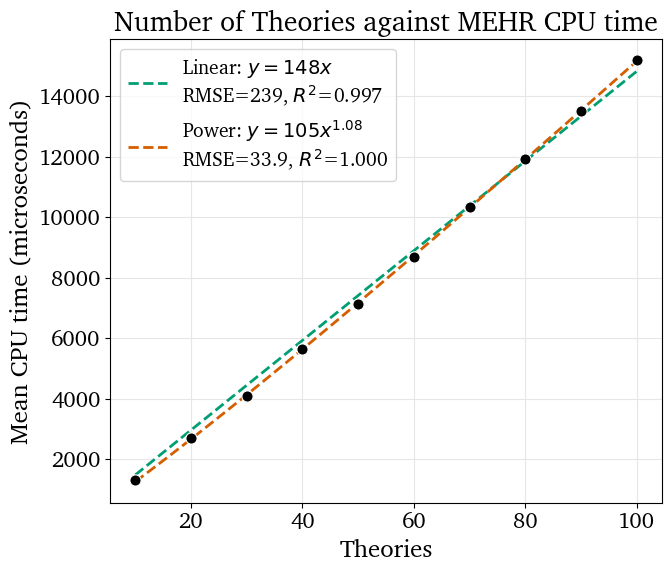

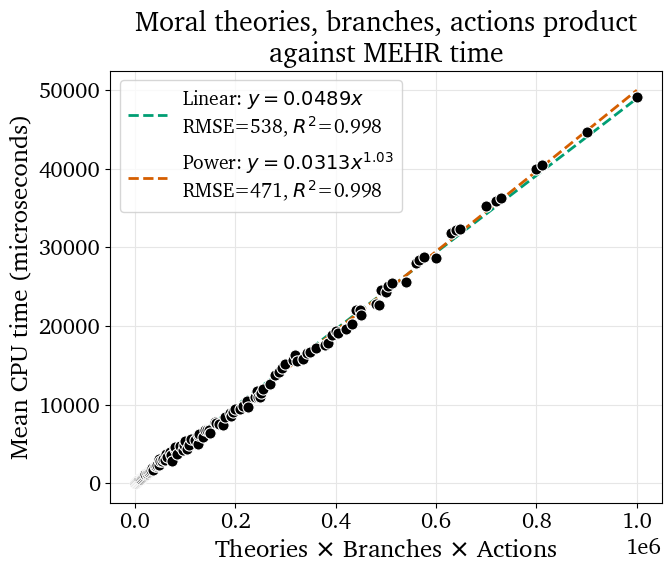

In [7]:
df_ = df.copy()
ProcessValue(df_, 'Actions')
ProcessValue(df_, 'Branches')
ProcessValue(df_, 'Theories')
ProcessValue(df_, 'N', val_name_label="Theories $\\times$ Branches $\\times$ Actions", title="Moral theories, branches, actions product\nagainst MEHR time")
